In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad

In [3]:
Allen_labs = pd.read_csv('../../Subclustering/PVH/Allen_labels_PVH_withcluster_09092026.csv',index_col='Unnamed: 0')

In [2]:
sam_mg = SAM()
sam_mg.load_data('../../Subclustering/PVH/SAM_Allen_Institute_directsub_PVH_08082026.h5ad')

sam_mo = SAM()
sam_mo.load_data('../../Subclustering/PVH/SAM_MO_soupx_cleaned_PVH_from0312205_09082026.h5ad')

sam_cj = SAM()
sam_cj.load_data('../../Subclustering/PVH/SAM_CJ_cleaned_PVH_09082026.h5ad')

sam_ac = SAM()
sam_ac.load_data('../../Subclustering/PVH/SAM_AC_soupx_cleaned_PVH_09082026.h5ad')

sam_xt = SAM()
sam_xt.load_data('../../Subclustering/PVH/SAM_XT_cleaned_PVH_09082026.h5ad')

sam_dr = SAM()
sam_dr.load_data('../../Subclustering/PVH/SAM_DR_cleaned_PVH_09082026.h5ad')

In [4]:
sam_mg.adata.obs['eq_supertype'] = Allen_labs['eq_supertype']

In [5]:
all_sup = set(sam_mg.adata.obs['eq_supertype'].unique()) | set(sam_mo.adata.obs['eq_supertype'].unique()) | set(sam_cj.adata.obs['eq_supertype'].unique()) | set(sam_ac.adata.obs['eq_supertype'].unique()) | set(sam_xt.adata.obs['eq_supertype'].unique()) | set(sam_dr.adata.obs['eq_supertype'].unique()) 

In [6]:
color_map_two = {'Avp':'#4FAE49',
                   'Crh': '#F37F20',
                   'Nkx2-2':'#83C6DB',
                   'Oxt':'#E12228',
                   'Sst':'#EC82B3',
                   'Trh':'#98509F',
                   'Ucn3':'#F6EC39'}

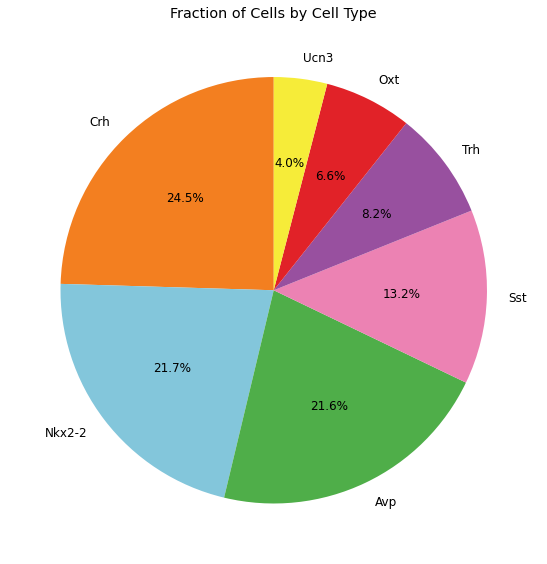

In [9]:
plt.rcParams['font.size'] = 12
level = 'eq_supertype'
counts = sam_mg.adata.obs[level].value_counts()

known = counts[counts.index.isin(color_map_two)]
unknown_total = counts[~counts.index.isin(color_map_two)].sum()

if unknown_total > 0:
    known["unlabeled"] = unknown_total

labels = known.index
colors = [color_map_two.get(ct, "#808080") for ct in known.index]

plt.figure(figsize=(8, 8))
plt.pie(known.values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors)

plt.title('Fraction of Cells by Cell Type')
plt.tight_layout()
plt.savefig('../../Figures/Figures_09132026/MG_PVH_cellfrac_piechart_09092026.svg',bbox_inches='tight')
plt.savefig('../../Figures/Figures_09132026/MG_PVH_cellfrac_piechart_09092026.pdf',bbox_inches='tight')
plt.show()